In [ ]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None
    
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        sorted_idx = np.argsort(eigenvalues)[::-1]
        sorted_eigenvectors = eigenvectors[:, sorted_idx]
        
        self.components = sorted_eigenvectors[:, :self.n_components]
    
    def transform(self, X):
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


In [3]:
import pandas as pd

In [4]:
data = pd.read_csv("../data/processed_smoke_detector.csv")
X = data.drop(labels=["Fire Alarm"], axis=1)
y = data["Fire Alarm"]

In [5]:
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_pca.shape

(41247, 2)

In [8]:
import matplotlib.pyplot as plt

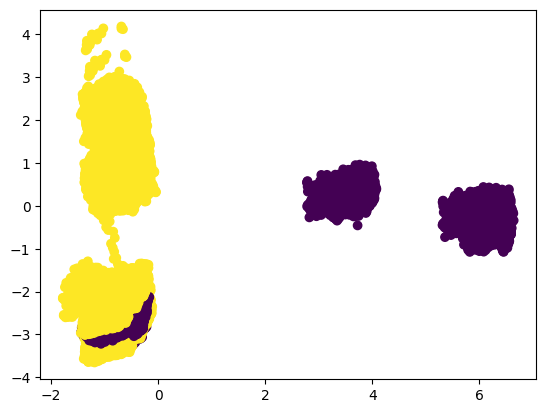

In [9]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [10]:
def test(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=2)
    knn.fit(X_train, y_train)
    y_bin_knn_pred = knn.predict(X_test)
    print(classification_report(y_test, y_bin_knn_pred))

In [12]:
test(X_pca, y)

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1810
           1       0.97      0.96      0.96      6440

    accuracy                           0.94      8250
   macro avg       0.92      0.92      0.92      8250
weighted avg       0.94      0.94      0.94      8250



# Кластеризация

In [15]:
import copy

In [16]:
def Kmeans(array, k, max_iter=1000, tol=1e-4):
    data = np.array(array)
    n = data.shape[0]
    
    indices = np.random.choice(n, size=k, replace=False)
    centroids = data[indices].tolist()
    
    for _ in range(max_iter):
        labels = data_distribution(data, centroids)
        
        old_centroids = copy.deepcopy(centroids)
        
        centroids = cluster_update(data, labels, k)
        
        if np.allclose(old_centroids, centroids, atol=tol):
            break
    
    return labels

def data_distribution(data, centroids):
    return [np.argmin([np.linalg.norm(point - c) for c in centroids]) 
            for point in data]

def cluster_update(data, labels, k):
    new_centroids = []
    for i in range(k):
        cluster_points = data[labels == i]
        if len(cluster_points) == 0:
            new_centroids.append(data[np.random.randint(len(data))].tolist())
            continue
        new_centroids.append(cluster_points.mean(axis=0).tolist())
    return new_centroids

In [18]:
labels = Kmeans(X_pca, 2, 100)

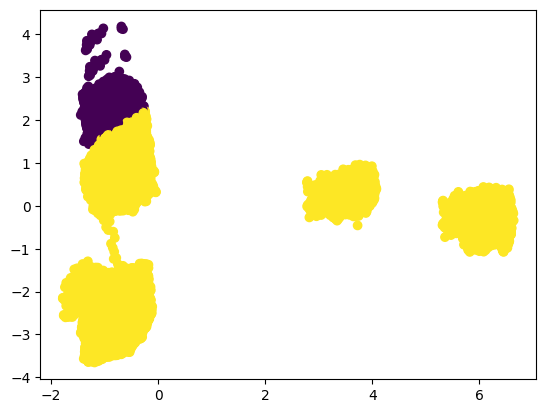

In [20]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

In [21]:
from sklearn.metrics import rand_score, adjusted_rand_score, silhouette_score, calinski_harabasz_score

In [22]:
print("Внешние метрики:")
print("rand score", rand_score(labels, y))
print("adjusted_rand_score", adjusted_rand_score(y, labels))
print("Внутренние метрики:")
print("silhouette_score: ", silhouette_score(X_pca, labels))
print("calinski_harabasz_score", calinski_harabasz_score(X_pca, labels))

Внешние метрики:
rand score 0.5841764519025128
adjusted_rand_score -0.07595926193058712
Внутренние метрики:
silhouette_score:  -0.04048894544099227
calinski_harabasz_score 2957.4968152401843
